# 🎬 Intelligent Movie Genre Classification & Recommendation System

### A Natural Language Processing and Machine Learning Approach

This project develops an intelligent movie analysis system that uses movie descriptions to predict their possible genres and recommend similar movies from the dataset.

The system applies text preprocessing and TF-IDF vectorization for feature extraction, a multi-label machine learning classifier for genre prediction, and cosine similarity for content-based movie recommendation.

### Key Technologies
- Python
- Natural Language Processing (NLP)
- TF-IDF
- Multi-Label Classification
- Logistic Regression
- Cosine Similarity
- Content-Based Recommendation

### Project Workflow

**Movie Description → Text Preprocessing → TF-IDF → Genre Prediction → Similarity Analysis → Movie Recommendation**

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn nltk sentence-transformers joblib openpyxl

In [ ]:
import os
import re
import ast
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    hamming_loss,
    jaccard_score,
    classification_report,
    multilabel_confusion_matrix
)

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

import nltk

SECTION 2 — Load Dataset

In [ ]:
# Section 2 – Load Dataset

df = pd.read_csv("/content/imdb_genres.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (300388, 5)


,movie title - year,genre,expanded-genres,rating,description
0,Black Panther: Wakanda Forever - 2022,Action,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...
1,Avatar: The Way of Water - 2022,Action,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...
2,Plane - 2023,Action,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...
3,Everything Everywhere All at Once - 2022,Action,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...
4,Fast X - 2023,Action,"Action, Crime, Mystery",NaN,Dom Toretto and his family are targeted by the...


SECTION 3 - Understand the Dataset

In [ ]:
print("Columns:")
print(df.columns.tolist())
print("\nDataset information:")
df.info()
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Columns:
['movie title - year', 'genre', 'expanded-genres', 'rating', 'description']

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300388 entries, 0 to 300387
Data columns (total 5 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   movie title - year  300388 non-null  object 
 1   genre               300388 non-null  object 
 2   expanded-genres     300388 non-null  object 
 3   rating              210722 non-null  float64
 4   description         300388 non-null  object 
dtypes: float64(1), object(4)
memory usage: 11.5+ MB

Missing values:
movie title - year        0
genre                     0
expanded-genres           0
rating                89666
description               0
dtype: int64

Duplicate rows: 28


In [ ]:
df = df[
    [
        "movie title - year",
        "genre",
        "expanded-genres",
        "rating",
        "description"
    ]
].copy()

df.head()

,movie title - year,genre,expanded-genres,rating,description
0,Black Panther: Wakanda Forever - 2022,Action,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...
1,Avatar: The Way of Water - 2022,Action,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...
2,Plane - 2023,Action,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...
3,Everything Everywhere All at Once - 2022,Action,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...
4,Fast X - 2023,Action,"Action, Crime, Mystery",NaN,Dom Toretto and his family are targeted by the...


SECTION 4 - Remove Unnecessary Columns

In [ ]:
df = df[
    [
        "movie title - year",
        "genre",
        "expanded-genres",
        "rating",
        "description"
    ]
].copy()

print(df.shape)
df.head()

(300388, 5)


,movie title - year,genre,expanded-genres,rating,description
0,Black Panther: Wakanda Forever - 2022,Action,"Action, Adventure, Drama",6.9,The people of Wakanda fight to protect their h...
1,Avatar: The Way of Water - 2022,Action,"Action, Adventure, Fantasy",7.8,Jake Sully lives with his newfound family form...
2,Plane - 2023,Action,"Action, Thriller",6.5,A pilot finds himself caught in a war zone aft...
3,Everything Everywhere All at Once - 2022,Action,"Action, Adventure, Comedy",8.0,A middle-aged Chinese immigrant is swept up in...
4,Fast X - 2023,Action,"Action, Crime, Mystery",NaN,Dom Toretto and his family are targeted by the...


SECTION 5 - Handle Missing Values

In [ ]:
df["description"] = df["description"].fillna("")
df["expanded-genres"] = df["expanded-genres"].fillna("[]")

df = df[df["description"].str.strip() != ""]

print("Shape after removing empty descriptions:", df.shape)

Shape after removing empty descriptions: (300388, 5)


SECTION 6 - Clean Movie Descriptions

In [ ]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_description"] = df["description"].fillna("").apply(clean_text)

df[["description", "clean_description"]].head()

,description,clean_description
0,The people of Wakanda fight to protect their h...,the people of wakanda fight to protect their h...
1,Jake Sully lives with his newfound family form...,jake sully lives with his newfound family form...
2,A pilot finds himself caught in a war zone aft...,a pilot finds himself caught in a war zone aft...
3,A middle-aged Chinese immigrant is swept up in...,a middle aged chinese immigrant is swept up in...
4,Dom Toretto and his family are targeted by the...,dom toretto and his family are targeted by the...


SECTION 7 - Convert Genre Labels into Lists

In [ ]:
# SECTION 7 – Convert Genre Labels into Lists

import ast
import re

def parse_genres(value):

    if pd.isna(value):
        return []

    # Already a Python list
    if isinstance(value, list):
        return [str(x).strip() for x in value if str(x).strip()]

    value = str(value).strip()

    if not value:
        return []

    # Try to convert strings such as:
    # "['Action', 'Drama']"
    try:
        parsed = ast.literal_eval(value)

        if isinstance(parsed, list):
            return [
                str(x).strip()
                for x in parsed
                if str(x).strip()
            ]

        if isinstance(parsed, str):
            value = parsed

    except:
        pass

    # Handle different separators
    value = re.sub(r"\s*\|\s*", ",", value)
    value = re.sub(r"\s*;\s*", ",", value)

    genres = [
        x.strip().strip("'\"")
        for x in value.split(",")
        if x.strip()
    ]

    return genres


df["genre_list"] = df["expanded-genres"].apply(parse_genres)

print(df["genre_list"].head(10))

0      [Action, Adventure, Drama]
1    [Action, Adventure, Fantasy]
2              [Action, Thriller]
3     [Action, Adventure, Comedy]
4        [Action, Crime, Mystery]
5     [Action, Adventure, Comedy]
6       [Action, Comedy, Romance]
7      [Action, Comedy, Thriller]
8            [Action, Drama, War]
9                 [Action, Drama]
Name: genre_list, dtype: object


In [ ]:
print("\nExample genre values:")

for i in range(min(10, len(df))):
    print(i, "→", df["genre_list"].iloc[i])


Example genre values:
0 → ['Action', 'Adventure', 'Drama']
1 → ['Action', 'Adventure', 'Fantasy']
2 → ['Action', 'Thriller']
3 → ['Action', 'Adventure', 'Comedy']
4 → ['Action', 'Crime', 'Mystery']
5 → ['Action', 'Adventure', 'Comedy']
6 → ['Action', 'Comedy', 'Romance']
7 → ['Action', 'Comedy', 'Thriller']
8 → ['Action', 'Drama', 'War']
9 → ['Action', 'Drama']


SECTION 8 - Clean Genre Names

In [ ]:
df["genre_list"] = df["genre_list"].apply(
    lambda genres: [
        str(g).strip().lower()
        for g in genres
        if str(g).strip()
    ]
)

df = df[df["genre_list"].apply(len) > 0]

print("Number of usable movies:", len(df))

Number of usable movies: 300388


SECTION 9 - Genre Distribution

         Genre   Count
2        drama  120759
0       action   85382
4     thriller   63775
6        crime   60800
5       comedy   57835
14      horror   52750
1    adventure   51984
8      romance   49126
7      mystery   32443
3      fantasy   26321
10      sci-fi   22376
15      family   21497
12   animation   16303
11     history   12146
13   biography   11795
9          war    9234
18       music    4575
17       sport    4475
20     musical    4127
19   film-noir    2556
16     western    2037
25  reality-tv      28
23        news      18
22   game-show       7
21       adult       7
24   talk-show       5
26       short       1


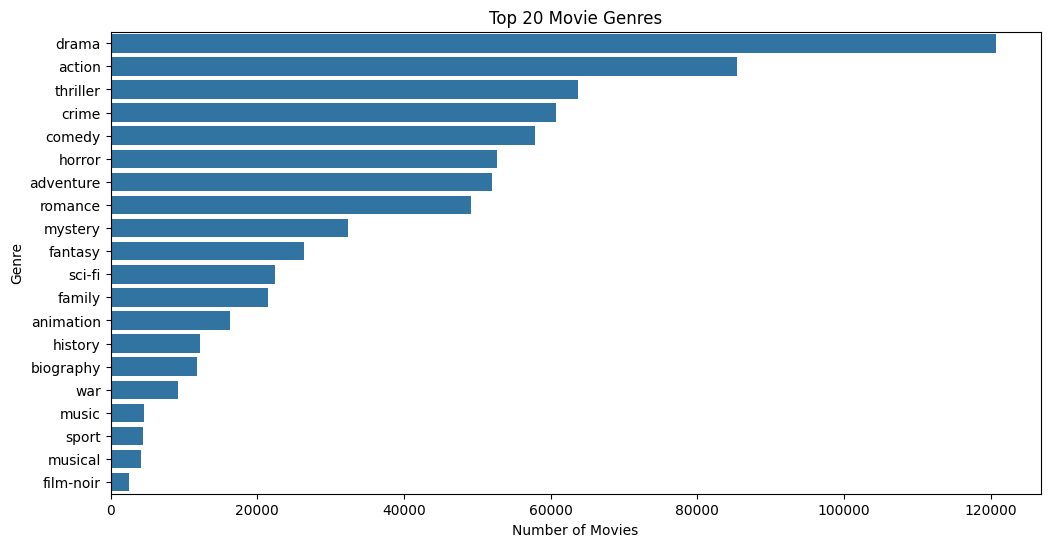

In [ ]:
from collections import Counter

genre_counts = Counter()

for genres in df["genre_list"]:
    for genre in genres:
        genre_counts[genre] += 1

genre_df = pd.DataFrame(
    genre_counts.items(),
    columns=["Genre", "Count"]
).sort_values("Count", ascending=False)

print(genre_df)

# Top 20 Genres

top_genres = genre_df.head(20)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_genres,
    x="Count",
    y="Genre"
)

plt.title("Top 20 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.show()

SECTION 10 - Prepare Features and Labels

In [ ]:
X = df["clean_description"]
y_labels = df["genre_list"]

print("Number of movies:", len(X))

print("\nExample Description:")
print(X.iloc[0])

print("\nExample Genre(s):")
print(y_labels.iloc[0])

Number of movies: 300388

Example Description:
the people of wakanda fight to protect their home from intervening world powers as they mourn the death of king t challa

Example Genre(s):
['action', 'adventure', 'drama']


SECTION 11 - Multi-Label Encoding

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

y = mlb.fit_transform(y_labels)

print("Number of genres:", len(mlb.classes_))

print("\nGenres:")
print(mlb.classes_)

print("\nEncoded label shape:", y.shape)

Number of genres: 27

Genres:
['action' 'adult' 'adventure' 'animation' 'biography' 'comedy' 'crime'
 'drama' 'family' 'fantasy' 'film-noir' 'game-show' 'history' 'horror'
 'music' 'musical' 'mystery' 'news' 'reality-tv' 'romance' 'sci-fi'
 'short' 'sport' 'talk-show' 'thriller' 'war' 'western']

Encoded label shape: (300388, 27)


SECTION 12 - Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 210271
Testing samples: 90117


SECTION 13 – TF-IDF Vectorization

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    stop_words="english"
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)

Training TF-IDF shape: (210271, 10000)
Testing TF-IDF shape: (90117, 10000)


Section 14 -Train the Logistic Regression

In [ ]:
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression

model = OneVsRestClassifier(
    LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )
)

model.fit(X_train_tfidf, y_train)

print("Model training completed.")

Model training completed.


SECTION 15 - Generate Predictions

In [ ]:
y_pred = model.predict(X_test_tfidf)

print("Prediction completed.")
print("Prediction shape:", y_pred.shape)

Prediction completed.
Prediction shape: (90117, 27)


SECTION 16 - Hamming Loss

In [ ]:
from sklearn.metrics import hamming_loss

hamming = hamming_loss(y_test, y_pred)

print("Hamming Loss:", hamming)

Hamming Loss: 0.1204853443609727


SECTION 17 - Precision, Recall and F1 Score

In [ ]:
# SECTION 17 – Accuracy, Precision, Recall and F1 Score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="micro",
    zero_division=0
)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.026188177591353463
Precision: 0.40035531010704406
Recall: 0.747928622920431
F1 Score: 0.5215385971268813


SECTION 18 - Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred,
        target_names=mlb.classes_,
        zero_division=0
    )
)

              precision    recall  f1-score   support

      action       0.56      0.74      0.64     25567
       adult       0.00      0.00      0.00         2
   adventure       0.43      0.74      0.54     15597
   animation       0.30      0.86      0.44      4861
   biography       0.27      0.85      0.41      3511
      comedy       0.39      0.70      0.50     17422
       crime       0.51      0.77      0.61     18258
       drama       0.58      0.69      0.63     36124
      family       0.27      0.80      0.40      6411
     fantasy       0.27      0.76      0.40      7822
   film-noir       0.20      0.87      0.33       765
   game-show       0.00      0.00      0.00         2
     history       0.27      0.86      0.41      3693
      horror       0.53      0.81      0.64     15786
       music       0.13      0.71      0.21      1408
     musical       0.09      0.64      0.15      1217
     mystery       0.28      0.72      0.41      9729
        news       0.00    

OVERALL MODEL PERFORMANCE
Precision : 0.4004
Recall    : 0.7479
F1-Score  : 0.5215

PER-GENRE F1 SCORE
     Genre  F1 Score
    horror  0.642095
    action  0.636892
     drama  0.631711
     crime  0.609977
   romance  0.561888
 adventure  0.543414
  thriller  0.514090
    comedy  0.503107
    sci-fi  0.489617
       war  0.480665
     sport  0.443195
 animation  0.439593
   mystery  0.408713
 biography  0.407833
   history  0.407220
reality-tv  0.400000
    family  0.399765
   fantasy  0.396817
 film-noir  0.326650
   western  0.236162
     music  0.213555
   musical  0.153511
     adult  0.000000
      news  0.000000
 game-show  0.000000
     short  0.000000
 talk-show  0.000000


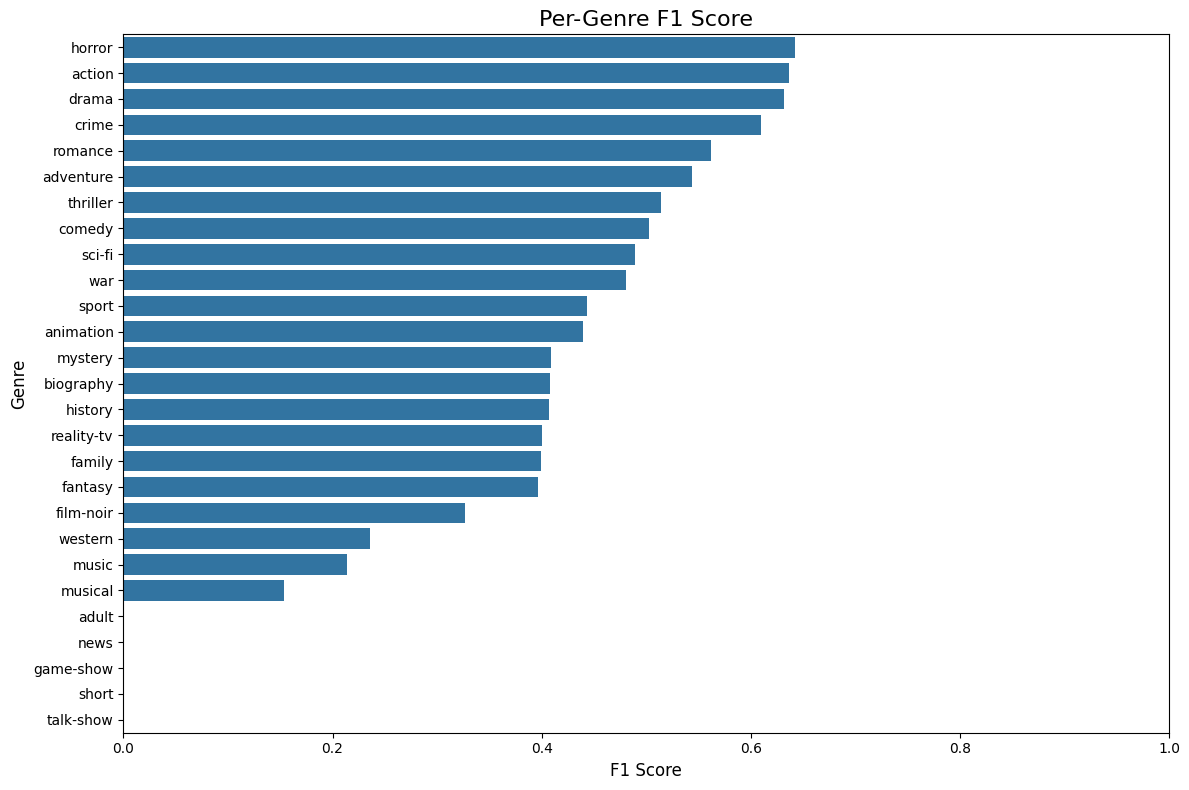

In [ ]:
# ============================================================
# RESULTS 2: CLASSIFICATION PERFORMANCE
# ============================================================

from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# ------------------------------------------------------------
# Generate Predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test_tfidf)


# ------------------------------------------------------------
# Generate Classification Report
# ------------------------------------------------------------

report = classification_report(
    y_test,
    y_pred,
    target_names=mlb.classes_,
    zero_division=0,
    output_dict=True
)


# ------------------------------------------------------------
# Overall Performance
# ------------------------------------------------------------

precision = report["micro avg"]["precision"]
recall = report["micro avg"]["recall"]
f1_score = report["micro avg"]["f1-score"]

print("OVERALL MODEL PERFORMANCE")
print("=" * 40)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1_score:.4f}")


# ------------------------------------------------------------
# Per-Genre F1 Score
# ------------------------------------------------------------

per_genre_f1 = pd.DataFrame({
    "Genre": mlb.classes_,
    "F1 Score": [
        report[genre]["f1-score"]
        for genre in mlb.classes_
    ]
})


# Sort F1 scores from highest to lowest

per_genre_f1 = per_genre_f1.sort_values(
    "F1 Score",
    ascending=False
).reset_index(drop=True)


print("\nPER-GENRE F1 SCORE")
print("=" * 40)

print(
    per_genre_f1.to_string(index=False)
)


# ------------------------------------------------------------
# Plot Per-Genre F1 Score
# ------------------------------------------------------------

plt.figure(figsize=(12, 8))

sns.barplot(
    data=per_genre_f1,
    x="F1 Score",
    y="Genre"
)

plt.title(
    "Per-Genre F1 Score",
    fontsize=16
)

plt.xlabel(
    "F1 Score",
    fontsize=12
)

plt.ylabel(
    "Genre",
    fontsize=12
)

plt.xlim(0, 1)

plt.tight_layout()

plt.show()

SECTION 19 - Actual vs Predicted Genres

In [ ]:
actual_genres = mlb.inverse_transform(y_test)
predicted_genres = mlb.inverse_transform(y_pred)

results = pd.DataFrame({
    "Movie Description": X_test.values,
    "Actual Genres": [
        ", ".join(genres) for genres in actual_genres
    ],
    "Predicted Genres": [
        ", ".join(genres) if genres else "No genre predicted"
        for genres in predicted_genres
    ]
})

results.head(10)

,Movie Description,Actual Genres,Predicted Genres
0,a film intended for bud abbott and lou costell...,"action, comedy","adventure, comedy, sci-fi"
1,an innocent asian boy born in a very average f...,thriller,"action, comedy, family, romance"
2,a family s dachshund is exiled by a jealous sh...,animation,"adventure, animation, biography, comedy, drama..."
3,the action crime thriller corrupted minds revo...,"action, crime, drama","action, crime, thriller"
4,eleanor and her parents are hunting big game a...,"adventure, family","action, adventure, romance"
5,a tokyo cyber punk yakuza and a bosnian mob en...,"action, comedy","action, crime"
6,after being fired from his job on the evening ...,"action, crime, drama","comedy, crime, drama, family, music, romance"
7,filmed with polaroid and super 8 footage overl...,romance,"adventure, biography, drama, fantasy, horror, ..."
8,a 1950 s supernatural neo noir thriller,"horror, thriller","crime, history, horror, mystery, thriller"
9,in november 1825 in the bolivian city of chuqu...,"biography, drama","adventure, biography, drama, history, war"


SECTION 20 - Test New Movie Descriptions

In [ ]:
# SECTION 20 – Test New Movie Descriptions

sample_movies = [
    "A detective investigates a series of mysterious murders and discovers a dangerous criminal conspiracy.",

    "A group of astronauts travel through space and encounter an alien civilization.",

    "Two young people fall in love while facing problems caused by their different family backgrounds.",

    "A group of friends must survive terrifying creatures after becoming trapped in an abandoned house."
]

sample_cleaned = [
    clean_text(movie)
    for movie in sample_movies
]

sample_tfidf = tfidf.transform(sample_cleaned)

sample_predictions = model.predict(sample_tfidf)

sample_genres = mlb.inverse_transform(sample_predictions)

for i in range(len(sample_movies)):

    print("\nMovie Description:")
    print(sample_movies[i])

    if sample_genres[i]:
        print("Predicted Genre(s):", ", ".join(sample_genres[i]))
    else:
        print("Predicted Genre(s): No genre predicted")


Movie Description:
A detective investigates a series of mysterious murders and discovers a dangerous criminal conspiracy.
Predicted Genre(s): action, crime, mystery, sci-fi, thriller

Movie Description:
A group of astronauts travel through space and encounter an alien civilization.
Predicted Genre(s): adventure, horror, sci-fi

Movie Description:
Two young people fall in love while facing problems caused by their different family backgrounds.
Predicted Genre(s): comedy, drama, family, musical, romance, war

Movie Description:
A group of friends must survive terrifying creatures after becoming trapped in an abandoned house.
Predicted Genre(s): horror, sci-fi, thriller


SECTION 21 — Prepare Unique Movies for Recommendation

In [ ]:
# Create a separate movie-level dataset
# Multiple rows belonging to the same movie will be combined.

movie_df = (
    df.groupby(
        ["movie title - year", "clean_description"],
        dropna=False
    )
    .agg({
        "genre_list": lambda x: sorted(
            set(
                genre
                for genres in x
                for genre in genres
            )
        )
    })
    .reset_index()
)

print("Original rows:", len(df))
print("Unique movies:", len(movie_df))

print("\nSample movies:")
print(movie_df.head())

Original rows: 300388
Unique movies: 189117

Sample movies:
        movie title - year                                  clean_description  \
0          "Giliap" - 1975  a man arrives in a swedish port city to work a...   
1        # (Hashtag) - nan  while investigating the mysterious disappearan...   
2  #1 Serial Killer - 2013  years of seething rage against the racism he s...   
3        #1915House - 2018  a century of secrets are hidden behind the fre...   
4                #5 - 2013  5 is a film about the creative process of maki...   

                     genre_list  
0                [crime, drama]  
1                    [thriller]  
2                      [horror]  
3            [horror, thriller]  
4  [biography, comedy, fantasy]  


SECTION 22 - Create TF-IDF and Recommendation Function

In [ ]:
# SECTION 22 – Movie Recommendation System

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Create TF-IDF representation for unique movies

recommendation_tfidf = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    max_features=20000
)

movie_vectors = recommendation_tfidf.fit_transform(
    movie_df["clean_description"]
)

print("Movie TF-IDF matrix shape:", movie_vectors.shape)


# Recommendation function

def recommend_movies(description, top_n=5):

    # Clean input description
    cleaned_description = clean_text(description)

    # Convert input description into TF-IDF
    query_vector = recommendation_tfidf.transform(
        [cleaned_description]
    )

    # Calculate cosine similarity
    similarity_scores = cosine_similarity(
        query_vector,
        movie_vectors
    ).flatten()

    # Get indices sorted by similarity
    top_indices = similarity_scores.argsort()[::-1]

    # Store selected movies
    selected_movies = []

    for index in top_indices:

        movie_title = movie_df.iloc[index]["movie title - year"]

        # Skip missing titles
        if pd.isna(movie_title):
            continue

        selected_movies.append(index)

        # Stop after required number of movies
        if len(selected_movies) == top_n:
            break

    # Create recommendation dataframe
    recommendations = movie_df.iloc[selected_movies].copy()

    recommendations["similarity_score"] = [
        similarity_scores[index]
        for index in selected_movies
    ]

    # Convert genre list into readable text
    recommendations["genres"] = recommendations[
        "genre_list"
    ].apply(
        lambda genres: ", ".join(
            genre.title() for genre in genres
        )
    )

    # Clean movie title display
    recommendations["movie"] = recommendations[
        "movie title - year"
    ].astype(str)

    # Remove "- nan" from movie names
    recommendations["movie"] = (
        recommendations["movie"]
        .str.replace(
            r"\s*-\s*nan$",
            "",
            regex=True
        )
        .str.strip()
    )

    return recommendations[
        [
            "movie",
            "genres",
            "similarity_score"
        ]
    ]

Movie TF-IDF matrix shape: (189117, 20000)


SECTION 23 - Test Movie Recommendations

In [ ]:
query = """
A chaotic family moves into a new house and gets involved in a series of hilarious situations while trying to adjust to their new neighborhood.
"""

# query = """
# A detective investigates a mysterious murder and discovers
# a dangerous conspiracy involving several powerful people.
# """

query = """
A journalist investigates a series of unexplained disappearances and uncovers a secret organization operating across the city.
"""


recommendations = recommend_movies(
    query,
    top_n=5
)

print("Input Description:")
print(query)

print("\nRecommended Movies:")

print(
    recommendations.to_string(index=False)
)

Input Description:

A journalist investigates a series of unexplained disappearances and uncovers a secret organization operating across the city.


Recommended Movies:
                      movie                   genres  similarity_score
     The Slender Man - 2017                   Horror          0.458143
          Bordertown - 2007 Crime, Mystery, Thriller          0.439977
   Unpublished Story - 1942               Drama, War          0.431455
         Sessiz harp - 1961         Adventure, Crime          0.315874
The Cornfield People - 2001                 Thriller          0.312188


SECTION 26 - Conclusion

The project developed an intelligent movie analysis and recommendation system based on movie descriptions.

The system first preprocesses and cleans the movie descriptions and converts the text into numerical features using TF-IDF. A multi-label classification model is then used to predict one or more genres for a given movie description.

In addition, the system uses cosine similarity to compare a user's movie description with existing movie descriptions in the dataset. Based on the similarity scores, it recommends the most relevant movies along with their genres.

Therefore, the final system can:

• Accept a movie description as input.<br>
• Predict the possible genre(s) of the movie.<br>
• Compare the description with movies in the dataset.<br>
• Recommend the most similar existing movies.<br>
• Display the recommended movie names, genres, and similarity scores.<br>

Overall, the project demonstrates how Natural Language Processing and Machine Learning can be used to understand movie descriptions, classify their genres, and provide content-based movie recommendations.